![banner](https://raw.githubusercontent.com/semilleroCV/Hands-on-Computer-Vision/refs/heads/main/sesiones/sesion9/Sesion9-banner.png)

<div align="center">

# Session 9. Optimization

## Hands-on: Image Deblurring, Analytical and Iterative Solutions

</div>

## What this notebook is about

Taking a sharp photograph and blurring it is easy. Recovering the sharp photograph from the
blurred one is not. This second task is called an *inverse problem*, and it is the reason why
optimization matters in computer vision.

The relation between the sharp image and the measured image is

$$\mathbf{y} = A\,\mathbf{x} + \mathbf{n}$$

where $\mathbf{x}$ is the sharp image (unknown), $A$ is the blurring operator (known),
$\mathbf{n}$ is measurement noise, and $\mathbf{y}$ is what the camera actually recorded.
The obvious idea is to compute $\mathbf{x} = A^{-1}\mathbf{y}$. This notebook shows why that
idea fails spectacularly, and what to do instead.

## How to work through this notebook

The notebook is built around sliders. Every slider stores its value in a global state, so the
parameters chosen with the mouse are the parameters used by all the cells below it.

The working loop is always the same:

1. Move a slider.
2. Re-run the cells that follow.
3. Observe what improved and what got worse.

Calling `status()` at any point prints the parameters that are currently active.

---

# Setup

Two quality metrics are used throughout the notebook. PSNR measures the average pixel error in
decibels, so higher is better and a difference of 1 dB is already visible. SSIM measures
structural similarity between 0 and 1, and it agrees better with human judgement than PSNR does.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": .25, "grid.linestyle": "--",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "bold", "font.size": 10,
    "legend.frameon": False, "lines.linewidth": 1.8,
    "image.cmap": "gray", "image.interpolation": "nearest",
})

COLORS = {"blue": "#2660A4", "red": "#C1121F", "green": "#2A9D8F",
          "orange": "#E76F51", "purple": "#6A4C93", "gray": "#6C757D"}


def psnr(x, ref):
    '''Peak signal to noise ratio in dB. Higher is better.'''
    mse = np.mean((np.clip(x, 0, 1) - ref)**2)
    return 99.0 if mse == 0 else 10*np.log10(1.0/mse)



from skimage.metrics import structural_similarity as _ssim
def ssim(x, ref):
    '''Structural similarity between 0 and 1. Higher is better.'''
    return _ssim(np.clip(x, 0, 1), ref, data_range=1.0)

def show(images, titles, ref=None, size=3.5):
    '''Displays a row of images. If ref is given, PSNR and SSIM are added to each title.'''
    fig, axes = plt.subplots(1, len(images), figsize=(size*len(images), size*1.15))
    for ax, im, title in zip(np.atleast_1d(axes), images, titles):
        ax.imshow(np.clip(im, 0, 1), vmin=0, vmax=1)
        if ref is not None and np.shape(im) == np.shape(ref):
            title = f"{title}\n{psnr(im, ref):.2f} dB, SSIM {ssim(im, ref):.3f}"
        ax.set_title(title, fontsize=9.5)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    fig.tight_layout(); plt.show()



from skimage.data import camera
from skimage.transform import resize
x_true = np.clip(resize(camera()/255.0, (256, 256), anti_aliasing=True), 0, 1)

# ---- interactive widgets (optional) -----------------------------------------
try:
    from ipywidgets import interact, FloatSlider, FloatLogSlider, IntSlider, Dropdown
    WIDGETS = True
except ImportError:
    WIDGETS = False
    print("Note: ipywidgets is not available. The default values will be used, and the")
    print("parameters can still be changed by editing the function calls by hand.")

STATE = dict(sigma_blur=2.0, noise=0.005, kind="gaussian", angle=30.0,
             lam=1e-3, method="Landweber", k_stop=20, lam_tv=5e-4, eps_tv=1e-2)

def status():
    '''Prints the parameters that are currently active in the notebook.'''
    print("Current state")
    print("-"*46)
    for key, value in STATE.items():
        print(f"   {key:<12} = {value}")
    print("-"*46)


print("Setup complete. Image size:", x_true.shape)
status()

Setup complete. Image size: (256, 256)
Current state
----------------------------------------------
   sigma_blur   = 2.0
   noise        = 0.005
   kind         = gaussian
   angle        = 30.0
   lam          = 0.001
   method       = Landweber
   k_stop       = 20
   lam_tv       = 0.0005
   eps_tv       = 0.01
----------------------------------------------


---

# 1. The forward problem

## 1.1 What blurring does

Blurring is a convolution of the sharp image with a small kernel called the Point Spread
Function, or PSF. The PSF describes what a single point of light looks like after passing
through the optical system. If the camera is out of focus, that point becomes a small disk or
a Gaussian blob. If the camera moved during the exposure, the point becomes a short streak.

The blurred image is then contaminated by noise coming from the sensor. The complete forward
model is $\mathbf{y} = A\mathbf{x} + \mathbf{n}$.

## 1.2 Why the operator is never stored as a matrix

The test image has 256 by 256 pixels, that is 65536 unknowns. Writing $A$ as an explicit matrix
would require 65536 by 65536 entries, roughly 34 GB of memory. That is not an option.

Fortunately it is not necessary. A convolution can be computed with the Fast Fourier Transform,
so the operator is applied through the function

$$A\mathbf{x} = \mathcal{F}^{-1}\big(H \cdot \mathcal{F}\mathbf{x}\big)$$

where $H$ is the Fourier transform of the PSF, usually called the Optical Transfer Function or
OTF. The transpose operator, which appears in every gradient computation, is obtained by
conjugating $H$. Both are one line of code each, and neither one builds a matrix.

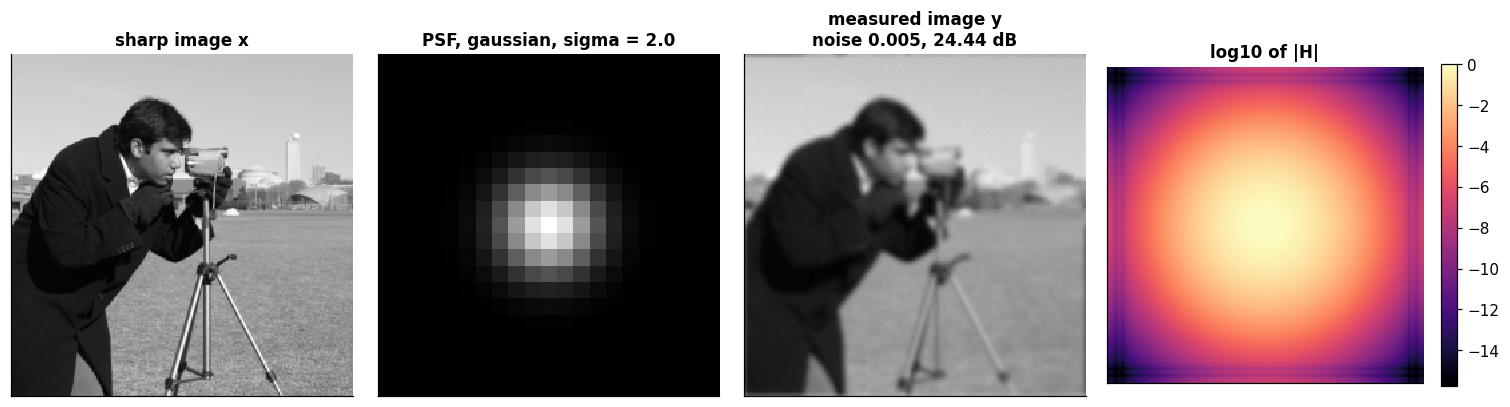

condition number of A: 1.29e+16
stored variables: psf, H, A, AT, y   (Landweber step = 1)


In [2]:

#  Point spread functions and the forward operator

def gaussian_psf(size=21, sigma=2.0):
    '''Out of focus blur'''
    axis = np.arange(size) - size//2
    xx, yy = np.meshgrid(axis, axis)
    kernel = np.exp(-(xx**2 + yy**2)/(2*sigma**2))
    return kernel/kernel.sum()


def motion_psf(size=21, angle=30.0):
    '''Motion blur'''
    kernel, center = np.zeros((size, size)), size//2
    for s in np.linspace(-center, center, 6*size):
        i = int(round(center + s*np.sin(np.deg2rad(angle))))
        j = int(round(center + s*np.cos(np.deg2rad(angle))))
        if 0 <= i < size and 0 <= j < size:
            kernel[i, j] += 1
    return kernel/kernel.sum()


def psf2otf(psf, shape):
    canvas = np.zeros(shape)
    h, w = psf.shape
    canvas[:h, :w] = psf
    canvas = np.roll(np.roll(canvas, -(h//2), axis=0), -(w//2), axis=1)
    return np.fft.fft2(canvas)


def set_problem(sigma_blur=2.0, noise=0.005, kind="gaussian", angle=30.0, plot=True):
    '''Build forward problem and stores psf, H, A, AT, y as global variables.'''
    global psf, H, A, AT, y, alpha_lw
    STATE.update(sigma_blur=sigma_blur, noise=noise, kind=kind, angle=angle)

    psf = gaussian_psf(21, sigma_blur) if kind == "gaussian" else motion_psf(21, angle)
    H   = psf2otf(psf, x_true.shape)
    A   = lambda z: np.real(np.fft.ifft2(H*np.fft.fft2(z)))
    AT  = lambda z: np.real(np.fft.ifft2(np.conj(H)*np.fft.fft2(z)))

    rng = np.random.default_rng(0)          # fixed seed, so comparisons are reproducible
    y   = A(x_true) + noise*rng.standard_normal(x_true.shape)
    alpha_lw = 1.0/np.max(np.abs(H)**2)     # safe step size for gradient descent

    if plot:
        fig, ax = plt.subplots(1, 4, figsize=(14, 3.6))
        ax[0].imshow(x_true, vmin=0, vmax=1)
        ax[0].set_title("sharp image x")
        ax[1].imshow(psf/psf.max())
        ax[1].set_title("PSF, " + (f"gaussian, sigma = {sigma_blur}" if kind == "gaussian"
                                   else f"motion, {angle:.0f} degrees"))
        ax[2].imshow(np.clip(y, 0, 1), vmin=0, vmax=1)
        ax[2].set_title(f"measured image y\nnoise {noise:g}, {psnr(y, x_true):.2f} dB")
        image = ax[3].imshow(np.log10(np.abs(np.fft.fftshift(H)) + 1e-16), cmap="magma")
        ax[3].set_title("log10 of |H|")
        plt.colorbar(image, ax=ax[3], fraction=.046)
        for a_ in ax:
            a_.set_xticks([]); a_.set_yticks([]); a_.grid(False)
        fig.tight_layout(); plt.show()
        print(f"condition number of A: {np.abs(H).max()/np.abs(H).min():.2e}")
        print(f"stored variables: psf, H, A, AT, y   (Landweber step = {alpha_lw:.3g})")


set_problem(**{k: STATE[k] for k in ("sigma_blur", "noise", "kind", "angle")})

## 1.3 Interactive panel

The sliders below define the forward problem for the rest of the notebook. Whatever values are
left in the panel are the values that every cell below will use.

The last plot deserves attention. It shows the magnitude of $H$, that is, how much of each
spatial frequency survives the blur. The center of the image corresponds to low frequencies
(large smooth structures) and the outside corresponds to high frequencies (fine detail and
edges). The dark outer region means that those frequencies were multiplied by a number very
close to zero. They were not damaged, they were erased.

That observation is the whole difficulty of the session. The last number printed by the cell,
the condition number, is the ratio between the largest and the smallest of those multipliers.
A well behaved problem has a condition number of a few units. Here it is around $10^{16}$.

In [3]:
# Move the sliders. The values left here define A and y for every cell below.
# After changing them, re-run the cells that follow.
if WIDGETS:
    interact(set_problem,
             sigma_blur=FloatSlider(STATE["sigma_blur"], min=0.5, max=5.0, step=0.25,
                                    description="blur sigma", continuous_update=False),
             noise=FloatLogSlider(STATE["noise"], base=10, min=-4, max=-1, step=0.25,
                                  description="noise", continuous_update=False),
             kind=Dropdown(options=["gaussian", "motion"], value=STATE["kind"],
                           description="PSF type"),
             angle=FloatSlider(STATE["angle"], min=0, max=180, step=5,
                               description="angle", continuous_update=False),
             plot=True);
else:
    set_problem(sigma_blur=2.0, noise=0.005)

interactive(children=(FloatSlider(value=2.0, continuous_update=False, description='blur sigma', max=5.0, min=0…

---

# 2. The direct inverse and why it fails

## 2.1 The idea that should work

Since the blur multiplies each frequency by a number $H$, undoing the blur should simply divide
by that same number.

$$\hat{X} = \frac{Y}{H} = \frac{H X + N}{H} = X + \frac{N}{H}$$

The first term is exactly the sharp image. The problem is the second one. Where the blur erased
a frequency, $H$ is close to zero, and the noise at that frequency gets divided by a number
close to zero.

## 2.2 What actually happens

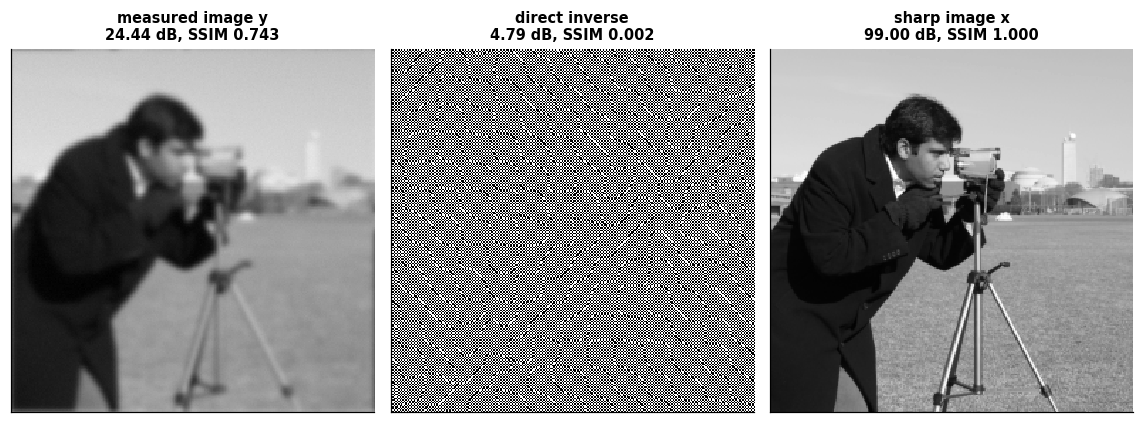

noise level used:        0.005
range of the result:     [-1.82e+13, 1.83e+13]
range it should have:    [0.00, 1.00]


In [4]:
x_naive = np.real(np.fft.ifft2(np.fft.fft2(y)/(H + 1e-16)))

show([y, x_naive, x_true],
     ["measured image y", "direct inverse", "sharp image x"], ref=x_true)

print(f"noise level used:        {STATE['noise']:g}")
print(f"range of the result:     [{x_naive.min():.2e}, {x_naive.max():.2e}]")
print( "range it should have:    [0.00, 1.00]")

The reconstruction is not slightly wrong, it is meaningless. Pixel values reach high magnitudes, when they should all live between 0 and 1.

The key point is that the input was almost perfect. The measured image was contaminated with a
noise of about half a percent, which is invisible to the eye. That invisible perturbation was
amplified into a result that is pure garbage. This is what the third Hadamard condition means:
the solution does not depend continuously on the data. A problem that violates it is called
ill-posed.

---

# 3. The analytical solution: Tikhonov and Wiener

## 3.1 Asking a better question

The direct inverse failed because it insisted on explaining the measurement exactly, including
the noise. A more modest question leads to a much better answer.

Instead of asking which image reproduces the data exactly, one asks which image explains the
data reasonably well without being absurd. The word absurd needs a mathematical definition, and
the previous section suggests an obvious one. The failed reconstruction had pixel values of
$10^{12}$, so absurd means enormous energy, that is, a large value of
$\|\mathbf{x}\|_2^2 = \sum_{ij} x_{ij}^2$.

Both wishes are written into a single cost function, which is then minimized:

$$\hat{\mathbf{x}}_\lambda = \arg\min_{\mathbf{x}} \;\;
\underbrace{\tfrac{1}{2}\|A\mathbf{x}-\mathbf{y}\|_2^2}_{\text{explain the data}}
\;+\;
\underbrace{\tfrac{\lambda}{2}\|\mathbf{x}\|_2^2}_{\text{stay reasonable}}$$

The first term is called the data fidelity term and the second one is called the regularizer.
The number $\lambda$ controls the balance between them, and it has a very concrete meaning:

| Value of $\lambda$ | What it tells the algorithm | Result |
|---|---|---|
| close to 0 | the measurement is completely trustworthy | the direct inverse, noise explodes |
| very large | the measurement is worthless | an almost black image |
| intermediate | trust the measurement, but stay sensible | a good reconstruction |

In other words, $\lambda$ is a dial for how much the measurement is trusted.

## 3.2 Solving the problem

The cost function is a convex quadratic, exactly like the parabolas of the first hands-on, only
in 65536 variables instead of one. The recipe is therefore the usual one: compute the gradient
and set it to zero.

$$\nabla f(\mathbf{x}) = A^\top(A\mathbf{x}-\mathbf{y}) + \lambda \mathbf{x} = 0
\qquad\Longrightarrow\qquad
(A^\top A + \lambda I)\,\mathbf{x} = A^\top \mathbf{y}$$

The term $\lambda I$ is what makes the difference. The eigenvalues of $A^\top A$ are essentially
zero, which is precisely why that matrix cannot be inverted. Adding $\lambda I$ shifts every
eigenvalue upward by $\lambda$:

$$\sigma_i^2 \approx 0
\qquad\longrightarrow\qquad
\sigma_i^2 + \lambda \;\ge\; \lambda \;>\; 0$$

Nothing is close to zero anymore, so the matrix is invertible, and the solution exists and is
unique. Regularization is not a numerical trick. It repairs the ill-posedness of the problem.

## 3.3 Solving 65536 equations instantly

There is still a system of 65536 equations to solve, and inverting such a matrix is out of the
question. This is where the structure of the blur becomes decisive.

An image can be described as a sum of waves of different frequencies. A convolution does
something remarkably simple to that description: it multiplies each wave by its own number and
never mixes one wave with another. Low frequency waves are multiplied by a number close to one
and survive. High frequency waves are multiplied by a number close to zero and disappear, which
is exactly what blurring looks like.

Because the waves do not interact, the enormous coupled problem separates into 65536 completely
independent problems, each one with a single unknown. And a problem with one unknown is
first year calculus. Writing $h$ for the multiplier of one particular wave, $x$ for its true
amplitude and $y$ for the measured one, the cost function for that single wave is

$$\min_{x}\;\; \tfrac{1}{2}(h\,x-y)^2 + \tfrac{\lambda}{2}x^2$$

Setting the derivative to zero gives $h(hx-y) + \lambda x = 0$, and therefore

$$\hat{x} = \frac{h\,y}{h^2+\lambda}$$

This derivation takes about thirty seconds on paper and it is worth doing, because it is the
entire method. Applying it to all the waves at once, and remembering that the amplitudes are
complex numbers so that $h$ becomes $\overline{H}$, gives the regularized Wiener filter:

$$\hat{X}_\lambda = \frac{\overline{H}\,Y}{|H|^{2}+\lambda}$$

Two Fourier transforms and one division, with no matrix ever built or inverted.

## 3.4 Reading the formula

The formula becomes much easier to interpret when it is factored like this:

$$\hat{X}_\lambda \;=\;
\underbrace{\frac{|H|^{2}}{|H|^{2}+\lambda}}_{\text{filter factor, between 0 and 1}}
\;\times\;
\underbrace{\frac{Y}{H}}_{\text{the direct inverse}}$$

Tikhonov regularization is therefore the direct inverse of section 2, with every frequency
multiplied by a dimmer switch that ranges from 0 to 1. The dimmer sets itself automatically.
When $|H|$ is much larger than $\sqrt{\lambda}$, the frequency was well preserved by the blur,
the factor is close to 1, and the information is kept untouched. When $|H|$ is much smaller
than $\sqrt{\lambda}$, the frequency was destroyed, the factor is close to 0, and it is switched
off before the division can amplify the noise.

The transition happens exactly at $|H| = \sqrt{\lambda}$, where the factor equals one half.
This means that $\sqrt{\lambda}$ acts as a cut-off frequency, and that choosing $\lambda$ is
the same as choosing where to stop trusting the measurement.

The next cell makes the dimmer switch visible.

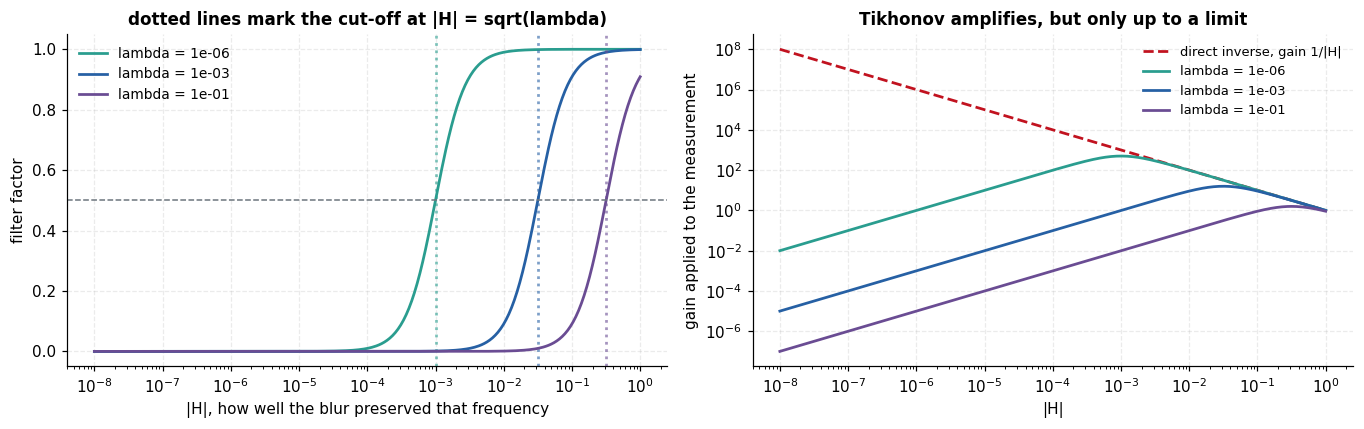

Largest amplification applied to the data
   direct inverse: unbounded
   lambda = 1e-06: 500 times
   lambda = 1e-03: 16 times
   lambda = 1e-01: 2 times


In [5]:
#  The filter factor, seen from two angles

h_axis = np.logspace(-8, 0, 400)
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.0))

for lam, color in zip([1e-6, 1e-3, 1e-1], [COLORS["green"], COLORS["blue"], COLORS["purple"]]):
    ax[0].semilogx(h_axis, h_axis**2/(h_axis**2 + lam), color=color, label=f"lambda = {lam:.0e}")
    ax[0].axvline(np.sqrt(lam), color=color, ls=":", alpha=.6)
ax[0].axhline(0.5, color=COLORS["gray"], ls="--", lw=1)
ax[0].set_xlabel("|H|, how well the blur preserved that frequency")
ax[0].set_ylabel("filter factor")
ax[0].set_title("dotted lines mark the cut-off at |H| = sqrt(lambda)")
ax[0].legend(fontsize=9)

ax[1].loglog(h_axis, 1/h_axis, color=COLORS["red"], ls="--",
             label="direct inverse, gain 1/|H|")
for lam, color in zip([1e-6, 1e-3, 1e-1], [COLORS["green"], COLORS["blue"], COLORS["purple"]]):
    ax[1].loglog(h_axis, h_axis/(h_axis**2 + lam), color=color, label=f"lambda = {lam:.0e}")
ax[1].set_xlabel("|H|"); ax[1].set_ylabel("gain applied to the measurement")
ax[1].set_title("Tikhonov amplifies, but only up to a limit")
ax[1].legend(fontsize=8.5)
fig.tight_layout(); plt.show()

print("Largest amplification applied to the data")
print("   direct inverse: unbounded")
for lam in [1e-6, 1e-3, 1e-1]:
    print(f"   lambda = {lam:.0e}: {1/(2*np.sqrt(lam)):.0f} times")

## 3.5 Trying it on the image

The function below applies the formula and stores the reconstruction in the global variable
`x_tik`, so that the final comparison of section 8 uses whatever value of $\lambda$ is left in
the slider.

A good exercise before running the sweep of the next section is to find the best $\lambda$ by
eye, moving the slider until the reconstruction looks sharpest without becoming grainy.

In [6]:
def tikhonov(y, H, lam):
    '''Regularized Wiener filter, the closed form solution.'''
    return np.real(np.fft.ifft2(np.conj(H)*np.fft.fft2(y)/(np.abs(H)**2 + lam)))


def set_lambda(lam=1e-3, plot=True):
    global x_tik
    STATE["lam"] = lam
    x_tik = np.clip(tikhonov(y, H, lam), 0, 1)
    if plot:
        show([y, x_tik, x_true],
             [f"measured image, noise {STATE['noise']:g}",
              f"Tikhonov, lambda = {lam:.2e}", "sharp image"], ref=x_true)
    return x_tik


if WIDGETS:
    interact(set_lambda,
             lam=FloatLogSlider(STATE["lam"], base=10, min=-7, max=0, step=0.1,
                                description="lambda", continuous_update=False),
             plot=True);
else:
    set_lambda(1e-3)

interactive(children=(FloatLogSlider(value=0.001, continuous_update=False, description='lambda', max=0.0, min=…

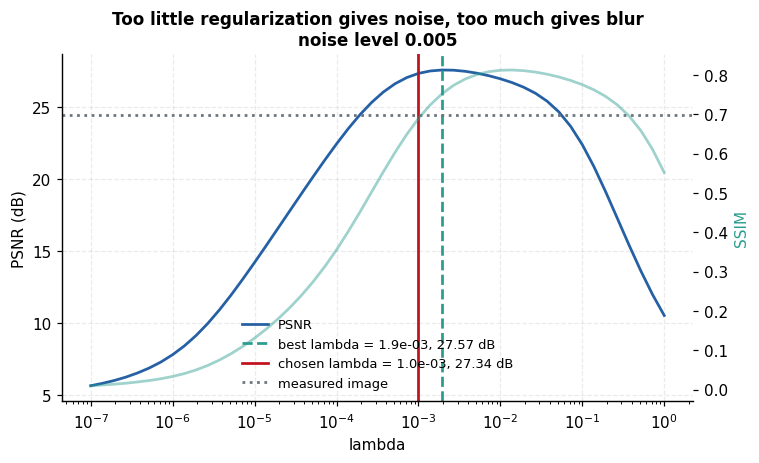

distance from the chosen lambda to the optimum: 0.24 dB
To adopt the optimal value for the rest of the notebook, run: set_lambda(lam_opt)


In [7]:
#  Sweep over lambda.
def sweep_lambda(y, H, grid=None):
    '''Returns the grid, the PSNR curve, the SSIM curve and the best lambda.'''
    grid = np.logspace(-7, 0, 50) if grid is None else grid
    curve_psnr = np.array([psnr(tikhonov(y, H, l), x_true) for l in grid])
    curve_ssim = np.array([ssim(tikhonov(y, H, l), x_true) for l in grid])
    return grid, curve_psnr, curve_ssim, grid[np.argmax(curve_psnr)]


grid, curve_psnr, curve_ssim, lam_opt = sweep_lambda(y, H)

fig, ax = plt.subplots(figsize=(7.4, 4.1))
ax.semilogx(grid, curve_psnr, color=COLORS["blue"], label="PSNR")
ax.axvline(lam_opt, color=COLORS["green"], ls="--",
           label=f"best lambda = {lam_opt:.1e}, {curve_psnr.max():.2f} dB")
ax.axvline(STATE["lam"], color=COLORS["red"],
           label=f"chosen lambda = {STATE['lam']:.1e}, {psnr(x_tik, x_true):.2f} dB")
ax.axhline(psnr(y, x_true), color=COLORS["gray"], ls=":", label="measured image")
ax.set_xlabel("lambda"); ax.set_ylabel("PSNR (dB)")
ax.set_title(f"Too little regularization gives noise, too much gives blur"
             f"\nnoise level {STATE['noise']:g}")
twin = ax.twinx(); twin.semilogx(grid, curve_ssim, color=COLORS["green"], alpha=.45)
twin.grid(False); twin.set_ylabel("SSIM", color=COLORS["green"])
ax.legend(loc="lower center", fontsize=8.5)
plt.show()

print(f"distance from the chosen lambda to the optimum: "
      f"{curve_psnr.max() - psnr(x_tik, x_true):.2f} dB")
print("To adopt the optimal value for the rest of the notebook, run: set_lambda(lam_opt)")

In [8]:
# Adopting the optimal lambda before continuing.
set_lambda(lam_opt, plot=False)
status()

Current state
----------------------------------------------
   sigma_blur   = 2.0
   noise        = 0.005
   kind         = gaussian
   angle        = 30.0
   lam          = 0.0019306977288832496
   method       = Landweber
   k_stop       = 20
   lam_tv       = 0.0005
   eps_tv       = 0.01
----------------------------------------------


## 3.6 Challenge 1: choosing lambda without the ground truth

Every value of $\lambda$ used so far was selected by looking at the PSNR curve, and that curve is
computed against `x_true`. In a real experiment the sharp image does not exist, so this procedure
is impossible. A criterion is needed that uses only the measurement.

The discrepancy principle, due to Morozov, provides one. The idea is that a reconstruction should
not explain the data better than the noise allows. If the noise has standard deviation $\sigma_n$
and the image has $N$ pixels, the expected size of the noise vector is

$$\mathbb{E}\,\|\mathbf{n}\|_2 \approx \sigma_n\sqrt{N}$$

so the right $\lambda$ is the one whose residual matches that value:

$$r(\lambda) \;=\; \|A\hat{\mathbf{x}}_\lambda-\mathbf{y}\|_2 \;=\; \tau\,\sigma_n\sqrt{N},
\qquad \tau\approx 1$$

Fitting the data more closely than this means fitting the noise itself.

### Why the equation can be solved by bisection

Two properties make the problem easy. The first is that $r(\lambda)$ is **monotonically
increasing**, which can be read directly from the filter factors of section 4: a larger $\lambda$
switches off more frequencies, so the reconstruction reproduces the measurement less faithfully.
The two extremes bracket the answer:

| $\lambda$ | filter factors | residual $r(\lambda)$ |
|---|---|---|
| $\to 0$ | all close to 1, the data is reproduced exactly | almost zero, far **below** the target |
| $\to \infty$ | all close to 0, the reconstruction vanishes | close to $\|\mathbf{y}\|$, far **above** the target |

A continuous increasing function that starts below the target and ends above it crosses it
exactly once. So the root exists, it is unique, and bisection will find it: keep an interval
$[\lambda_{lo}, \lambda_{hi}]$ whose endpoints are known to sit on opposite sides of the target,
and shrink it by half at every step. The invariant to preserve is

$$r(\lambda_{lo}) \le \text{target} \le r(\lambda_{hi})$$

and each iteration replaces whichever endpoint the midpoint can safely take over, without ever
breaking that invariant.

The second property is that $\lambda$ spans many orders of magnitude, from $10^{-9}$ to $10$ in
the code below. Halving that interval arithmetically would waste almost every iteration in the
large values. Bisecting the **logarithm** instead is what the geometric midpoint
$\sqrt{\lambda_{lo}\lambda_{hi}}$ does, and it divides the exponent range by two at each step.
With fifty iterations the bracket shrinks by a factor of $2^{50}$, which is far more precision
than needed.

### Tasks

The cell below implements everything except the update rule, which is the algorithm itself. As
written it runs, but it simply returns the midpoint of the initial bracket, which is not a
solution and gives a visibly poor reconstruction.

1. Write the update. Only one of the two endpoints has to move at each iteration, and deciding
   which one is exactly the question of which side of the target the current residual falls on.
   Reason with the table above: if the reconstruction fits the data *less* than the noise
   justifies, was the current $\lambda$ too large or too small?
2. Verify that it converged. Printing `residual/target` inside the loop should approach 1, and
   `hi/lo` should collapse towards 1 as well. If the bracket shrinks but the residual does not
   approach the target, the update is moving the wrong endpoint.
3. Compare the resulting $\lambda$ and its PSNR against the optimum found by the sweep of
   section 4, and report how many decibels are lost by not knowing the sharp image. Repeat with
   $\tau = 1.1$ and $\tau = 0.9$ to see how sensitive the criterion is to the assumed noise level.

Morozov, uses only the measurement : lambda = 1.00e-04, 22.44 dB
Sweep, needs the sharp image       : lambda = 1.93e-03, 27.57 dB
price of not knowing the truth     : 5.13 dB


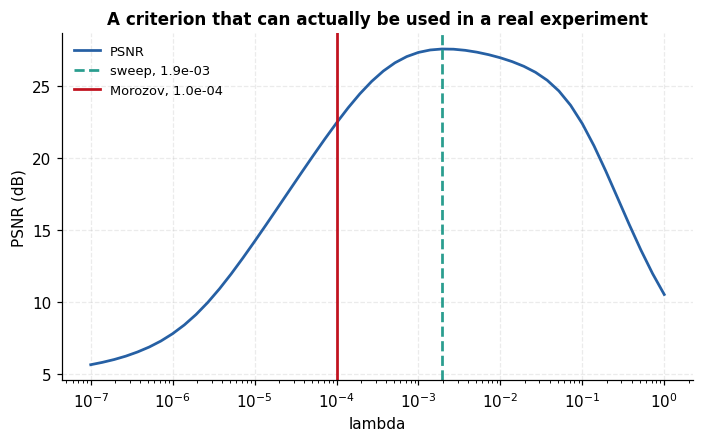

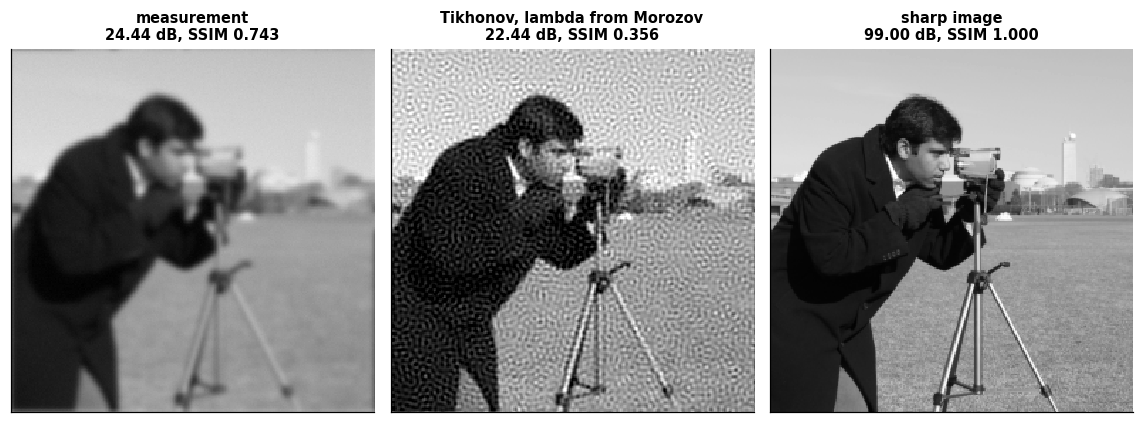

In [9]:
#  Challenge 1. Complete the TODO item.

def morozov(A, y, H, sigma_n, tau=1.0, n_bisect=50, lo=1e-9, hi=1e1):
    """Discrepancy principle: find lambda with ||A x_lam - y|| = tau*sigma_n*sqrt(N)."""
    target = tau*sigma_n*np.sqrt(y.size)

    for _ in range(n_bisect):
        mid = np.sqrt(lo*hi)                       # geometric midpoint
        residual = np.linalg.norm(A(tikhonov(y, H, mid)) - y)

        # TODO: update the bracket, keeping r(lo) <= target <= r(hi).
        #       Exactly one of lo or hi should be replaced by mid.
        #       Use the fact that the residual grows with lambda.
        lo, hi = lo, hi

    lam = np.sqrt(lo*hi)
    return lam, np.clip(tikhonov(y, H, lam), 0, 1)


lam_morozov, x_morozov = morozov(A, y, H, sigma_n=STATE["noise"])

grid, curve_psnr, _, lam_opt = sweep_lambda(y, H)
print(f"Morozov, uses only the measurement : lambda = {lam_morozov:.2e}, "
      f"{psnr(x_morozov, x_true):.2f} dB")
print(f"Sweep, needs the sharp image       : lambda = {lam_opt:.2e}, "
      f"{curve_psnr.max():.2f} dB")
print(f"price of not knowing the truth     : "
      f"{curve_psnr.max() - psnr(x_morozov, x_true):.2f} dB")

fig, ax = plt.subplots(figsize=(7.4, 4.1))
ax.semilogx(grid, curve_psnr, color=COLORS["blue"], label="PSNR")
ax.axvline(lam_opt, color=COLORS["green"], ls="--", label=f"sweep, {lam_opt:.1e}")
ax.axvline(lam_morozov, color=COLORS["red"], label=f"Morozov, {lam_morozov:.1e}")
ax.set_xlabel("lambda"); ax.set_ylabel("PSNR (dB)")
ax.set_title("A criterion that can actually be used in a real experiment")
ax.legend(fontsize=8.5)
plt.show()

show([y, x_morozov, x_true], ["measurement", "Tikhonov, lambda from Morozov", "sharp image"],
     ref=x_true)

---

# 4. The iterative solution

## 4.1 Why a closed form is not enough

The formula of section 4 works because circular convolution treats every frequency
independently. That is a rare privilege. As soon as the operator changes, for instance when the
blur varies across the image, when some pixels are missing, or when the measurement comes from
a tomograph, the frequencies get mixed and the closed form disappears.

What does not disappear is the optimization problem itself:

$$f(\mathbf{x}) = \tfrac{1}{2}\|A\mathbf{x}-\mathbf{y}\|_2^2,
\qquad
\nabla f(\mathbf{x}) = A^\top(A\mathbf{x}-\mathbf{y})$$

This is the same quadratic function studied in the first hands-on, and it can be minimized with
the same tools. Two of them are implemented below.

Landweber iteration is plain gradient descent applied to this cost function,

$$\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha A^\top(A\mathbf{x}_k-\mathbf{y})$$

with a step size $\alpha$ smaller than $2/\|A\|^2$. Conjugate gradient, denoted CGLS here, is
the accelerated version that remembers previous directions. Both methods only need to apply
$A$ and $A^\top$, never to invert anything.

## 4.2 An unexpected behaviour

The next cell runs both methods and records the PSNR at every iteration. The result is
surprising the first time it is seen.

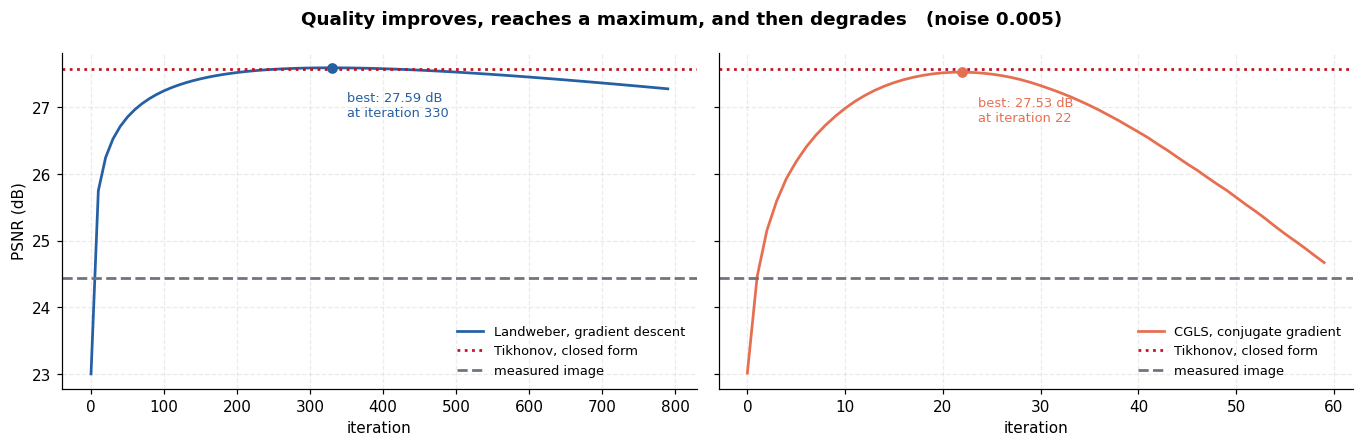

In [10]:
def landweber(A, AT, y, n_iter, alpha, keep_every=10):
    '''Gradient descent on 0.5*||Ax-y||^2. Returns the stored iterates.'''
    x, frames = np.zeros_like(y), []
    for k in range(n_iter):
        x = x - alpha*AT(A(x) - y)
        if k % keep_every == 0:
            frames.append(x.copy())
    return frames


def cgls(A, AT, y, n_iter, lam=0.0, keep_every=1):
    '''Conjugate gradient on the normal equations. Returns the stored iterates.'''
    x = np.zeros_like(y)
    r = AT(y) - (AT(A(x)) + lam*x)
    d = r.copy()
    rs = np.sum(r*r)
    frames = []
    for k in range(n_iter):
        Ad = AT(A(d)) + lam*d
        denominator = np.sum(d*Ad)
        if denominator <= 1e-30 or not np.isfinite(denominator):
            break
        step = rs/denominator
        x += step*d
        r -= step*Ad
        rs_new = np.sum(r*r)
        d = r + (rs_new/rs)*d
        rs = rs_new
        if k % keep_every == 0:
            frames.append(x.copy())
    return frames


def compute_iterates(n_landweber=800, n_cgls=60):
    '''Runs both solvers on the current A, AT and y, and stores the histories.'''
    global lw_frames, cg_frames, lw_psnr, cg_psnr, LW_STEP
    LW_STEP = 10
    lw_frames = landweber(A, AT, y, n_landweber, alpha_lw, keep_every=LW_STEP)
    cg_frames = cgls(A, AT, y, n_cgls, lam=0.0, keep_every=1)
    lw_psnr = np.array([psnr(f, x_true) for f in lw_frames])
    cg_psnr = np.array([psnr(f, x_true) for f in cg_frames])


compute_iterates()      # re-run this cell after changing the forward problem

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.1), sharey=True)
panels = [(np.arange(len(lw_psnr))*LW_STEP, lw_psnr, COLORS["blue"], "Landweber, gradient descent"),
          (np.arange(len(cg_psnr)),         cg_psnr, COLORS["orange"], "CGLS, conjugate gradient")]
for ax, (iters, curve, color, name) in zip(axes, panels):
    ax.plot(iters, curve, color=color, label=name)
    ax.scatter([iters[np.argmax(curve)]], [curve.max()], color=color, zorder=5)
    ax.annotate(f"best: {curve.max():.2f} dB\nat iteration {iters[np.argmax(curve)]}",
                (iters[np.argmax(curve)], curve.max()), textcoords="offset points",
                xytext=(10, -32), fontsize=8.5, color=color)
    ax.axhline(psnr(x_tik, x_true), color=COLORS["red"], ls=":", label="Tikhonov, closed form")
    ax.axhline(psnr(y, x_true), color=COLORS["gray"], ls="--", label="measured image")
    ax.set_xlabel("iteration"); ax.legend(fontsize=8.5, loc="lower right")
axes[0].set_ylabel("PSNR (dB)")
fig.suptitle(f"Quality improves, reaches a maximum, and then degrades"
             f"   (noise {STATE['noise']:g})", fontsize=12, fontweight="bold")
fig.tight_layout(); plt.show()

## 4.3 Semi-convergence

The quality does not improve forever. It rises, reaches a maximum, and then falls, even though
the algorithm keeps reducing the cost function correctly at every step. This behaviour is called
semi-convergence.

The explanation follows from section 4. The iterations recover first the frequencies that the
blur preserved, because those are the ones where the gradient is large. The frequencies that the
blur nearly erased are recovered last, very slowly, and those are precisely the ones dominated
by noise. So the early iterations reconstruct the image and the late iterations reconstruct the
noise.

The practical consequence is important: stopping early is a form of regularization. The
iteration counter plays the same role as $\lambda$, and choosing when to stop is the same kind of
decision as choosing how much to trust the data.

The slider below stores the chosen method and stopping point in the global state.

In [11]:
def set_stop(method="Landweber", k=20, plot=True):
    global x_iter
    frames, step = (lw_frames, LW_STEP) if method == "Landweber" else (cg_frames, 1)
    index = int(min(k//step, len(frames)-1))
    STATE.update(method=method, k_stop=index*step)
    x_iter = np.clip(frames[index], 0, 1)
    if plot:
        show([y, x_iter, x_true],
             ["measured image", f"{method}, stopped at iteration {index*step}", "sharp image"],
             ref=x_true)
    return x_iter


if WIDGETS:
    interact(set_stop,
             method=Dropdown(options=["Landweber", "CGLS"], value=STATE["method"],
                             description="method"),
             k=IntSlider(STATE["k_stop"], min=0, max=200, step=10,
                         description="stop at", continuous_update=False),
             plot=True);
else:
    set_stop("Landweber", int(np.argmax(lw_psnr)*10))

interactive(children=(Dropdown(description='method', options=('Landweber', 'CGLS'), value='Landweber'), IntSli…

## 4.4 Challenge 4: choosing the step size by yourself

Landweber uses the fixed step $\alpha = 1/\|A\|^2$. It is safe, because it sits below the
divergence threshold $2/\|A\|^2$ established in the first hands-on, but safe and good are not
the same thing. For a quadratic cost function the best possible step along the current direction
can be computed exactly, and the derivation takes three lines.

### Deriving the step

Along the descent direction the cost becomes a function of a single scalar,

$$\phi(\alpha) = f(\mathbf{x}_k - \alpha \mathbf{g}_k)
= \tfrac{1}{2}\|A(\mathbf{x}_k-\alpha\mathbf{g}_k)-\mathbf{y}\|_2^2,
\qquad \mathbf{g}_k = A^\top(A\mathbf{x}_k-\mathbf{y})$$

Writing $\mathbf{r}_k = A\mathbf{x}_k-\mathbf{y}$ and expanding the square gives a parabola in
$\alpha$,

$$\phi(\alpha) = \tfrac{1}{2}\|\mathbf{r}_k\|^2
- \alpha\,\mathbf{r}_k^\top A\mathbf{g}_k
+ \tfrac{\alpha^2}{2}\|A\mathbf{g}_k\|^2$$

whose derivative vanishes at a single point. Using $\mathbf{r}_k^\top A\mathbf{g}_k =
\mathbf{g}_k^\top A^\top \mathbf{r}_k = \|\mathbf{g}_k\|^2$, the result is

$$\alpha_k = \frac{\|\mathbf{g}_k\|_2^2}{\|A\mathbf{g}_k\|_2^2}$$

This is a parabola opening upwards, so the critical point is a minimum and the step is always
positive. Note what it costs: the denominator needs one extra application of $A$, so an
iteration of steepest descent uses three operator applications instead of the two used by
Landweber. Whether that extra third pays for itself is the question this challenge answers.

### Steps to follow

The cell below runs as it stands, but with a placeholder step equal to the Landweber one, so it
currently reproduces plain gradient descent and the blue curve lies on top of the grey one.

1. Inside the loop, apply the operator to the gradient once and store it in a variable, for
   instance `Ag`. Do not write `A(g)` twice: applying the operator two times would cancel the
   advantage the method is supposed to have, and in inverse problems the cost is counted in
   operator applications, not in floating point operations.
2. Build the step from that variable, following the formula derived above. Both the numerator
   and the denominator are sums of squares over the whole image, so `np.sum(g*g)` and
   `np.sum(Ag*Ag)` are the two quantities needed.
3. Complete the projection. It is a single line, guarded by the `project` flag, applied after
   the update and before the iterate is stored.
4. Re-run the cell and read the two panels.

### Questions to answer

1. Compare the iteration at which each method reaches its best PSNR. Then convert both numbers
   into operator applications, three per iteration for steepest descent and two for Landweber,
   and compare again. Does the conclusion change? Comparing methods by iteration count when the
   cost per iteration differs is a common and misleading habit.
2. Look at the right panel. The fixed step is drawn as a dashed line. By what factor was the
   safe choice too conservative, and does $\alpha_k$ remain constant along the run? Relate the
   answer to the zig-zag trajectories seen in the first hands-on: the step has to change because
   the curvature felt along each new gradient direction is different.
3. The projected version gains very little here. Explain why, given that Tikhonov and early
   stopping already keep the iterates inside a sensible range, and predict in which situation the
   constraint would matter much more. The inpainting challenge of section 9, where half of the
   pixels carry no information at all, is the natural place to test that prediction.

In [12]:
#  Challenge 2. Complete the two TODO items.

def steepest_descent(A, AT, y, n_iter=300, project=False):
    """Gradient descent with exact line search. Returns iterates, PSNR curve and steps."""
    x = np.zeros_like(y)
    frames, curve, steps = [], [], []

    for k in range(n_iter):
        g =                 # gradient of 0.5*||Ax-y||^2

        # TODO 1: replace the placeholder by the exact line search step,

        alpha = alpha_lw

        x = x - alpha*g

        # TODO 2: if project is True, clip x to the interval [0, 1].

        frames.append(x.copy()); curve.append(psnr(x, x_true)); steps.append(alpha)

    return frames, np.array(curve), np.array(steps)


sd_frames, sd_curve, sd_steps = steepest_descent(A, AT, y, n_iter=300)
pj_frames, pj_curve, _        = steepest_descent(A, AT, y, n_iter=300, project=True)

x_land = np.zeros_like(y)
land_curve = []
for k in range(300):
    x_land = x_land - alpha_lw*AT(A(x_land) - y)
    land_curve.append(psnr(x_land, x_true))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.1))
axes[0].plot(land_curve, color=COLORS["gray"], label=f"Landweber, fixed step {alpha_lw:.3g}")
axes[0].plot(sd_curve,   color=COLORS["blue"],  label="steepest descent, exact line search")
axes[0].plot(pj_curve,   color=COLORS["green"], label="steepest descent, projected on [0,1]")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("PSNR (dB)")
axes[0].set_title("Does the extra operator application pay for itself?")
axes[0].legend(fontsize=8.5, loc="lower right")

axes[1].plot(sd_steps, color=COLORS["red"], label="step chosen by the line search")
axes[1].axhline(alpha_lw, color=COLORS["gray"], ls="--", label="fixed Landweber step")
axes[1].set_xlabel("iteration"); axes[1].set_ylabel("alpha")
axes[1].set_title("The step the algorithm selects by itself")
axes[1].legend(fontsize=8.5)
fig.tight_layout(); plt.show()

print(f"steepest descent : best {sd_curve.max():.2f} dB at iteration {sd_curve.argmax()}")
print(f"projected version: best {pj_curve.max():.2f} dB at iteration {pj_curve.argmax()}")
print(f"Landweber        : {land_curve[-1]:.2f} dB after 300 iterations")

show([y, np.clip(sd_frames[int(sd_curve.argmax())], 0, 1), x_true],
     ["measurement", f"steepest descent, stopped at {sd_curve.argmax()}", "sharp image"],
     ref=x_true)

SyntaxError: invalid syntax (2678153899.py, line 9)

---

# 7. A better prior: Total Variation

## 7.1 What the previous prior was really saying

The regularizer $\|\mathbf{x}\|_2^2$ was chosen for convenience, and its message to the
algorithm is simply that the image should have little energy. That is a weak statement, and it
is not even true for a photograph.

A far better statement is that natural images are smooth in most places and change abruptly only
along edges. The quantity that measures this is Total Variation, the sum of the magnitudes of
the image gradient:

$$\min_{\mathbf{x}}\;\; \tfrac{1}{2}\|A\mathbf{x}-\mathbf{y}\|^2
+ \lambda \sum_{i,j}\sqrt{(\nabla_x \mathbf{x})^2+(\nabla_y \mathbf{x})^2+\varepsilon^2}$$

The small constant $\varepsilon$ is there to keep the square root differentiable at zero, which
allows the problem to be solved with gradient based methods.

Because this cost function is not quadratic, there is no closed form solution. Iteration is now
mandatory, which is exactly why section 6 was necessary. The algorithm used here is FISTA,
gradient descent with Nesterov momentum, the accelerated method from the first hands-on.

In [ ]:
def grad_xy(x):
    '''Forward differences along the two axes.'''
    return np.roll(x, -1, axis=1) - x, np.roll(x, -1, axis=0) - x


def div_xy(p, q):
    '''Discrete divergence, the adjoint of grad_xy up to a sign.'''
    return (p - np.roll(p, 1, axis=1)) + (q - np.roll(q, 1, axis=0))


def set_tv(lam_tv=5e-4, eps_tv=1e-2, n_iter=250, plot=True):
    '''TV regularized deblurring with FISTA.'''
    global x_tv
    STATE.update(lam_tv=lam_tv, eps_tv=eps_tv)
    x = np.zeros_like(y)
    z = x.copy()
    t = 1.0
    step = 1.0/(np.max(np.abs(H)**2) + lam_tv*8.0/eps_tv)     # one over the Lipschitz constant
    for _ in range(n_iter):
        gx, gy = grad_xy(z)
        magnitude = np.sqrt(gx**2 + gy**2 + eps_tv**2)
        gradient = AT(A(z) - y) - lam_tv*div_xy(gx/magnitude, gy/magnitude)
        x_new = z - step*gradient
        t_new = 0.5*(1 + np.sqrt(1 + 4*t*t))
        z = x_new + ((t - 1)/t_new)*(x_new - x)
        x, t = x_new, t_new
    x_tv = np.clip(x, 0, 1)
    if plot:
        show([y, x_tik, x_tv, x_true],
             ["measured image", "Tikhonov", f"Total Variation, lambda = {lam_tv:.1e}",
              "sharp image"], ref=x_true, size=3.2)
    return x_tv

if WIDGETS:
    interact(set_tv,
             lam_tv=FloatLogSlider(STATE["lam_tv"], base=10, min=-5, max=-1.5, step=0.1,
                                   description="lambda TV", continuous_update=False),
             eps_tv=FloatLogSlider(STATE["eps_tv"], base=10, min=-3, max=-1, step=0.25,
                                   description="epsilon", continuous_update=False),
             n_iter=IntSlider(250, min=50, max=500, step=50, description="iterations",
                              continuous_update=False),
             plot=True);
else:
    set_tv()

---

# 8. Final comparison

**The cell below collects every reconstruction produced so far, using the parameters currently
stored in the global state. It should be re-executed after any change to the sliders.**

One warning before drawing conclusions. If the blur or the noise were modified, the value of
$\lambda$ chosen earlier is probably no longer appropriate, and the same applies to the stopping
iteration and to the TV parameters. Comparing methods whose hyperparameters were tuned for a
different problem is the most common mistake in papers on inverse problems. The honest procedure
is to re-run the sweep of section 4, call `set_lambda(lam_opt)`, run `compute_iterates()` again,
and re-tune the TV slider before declaring a winner.

In [ ]:
status()

results = {
    "measured image":                              np.clip(y, 0, 1),
    "direct inverse":                              np.clip(x_naive, 0, 1),
    f"Tikhonov, lambda {STATE['lam']:.1e}":        x_tik,
    f"{STATE['method']}, iteration {STATE['k_stop']}": x_iter,
    f"Total Variation, lambda {STATE['lam_tv']:.1e}":  x_tv,
    "sharp image":                                 x_true,
}

show(list(results.values()), list(results.keys()), ref=x_true, size=2.9)

detail = (slice(60, 150), slice(80, 170))
show([image[detail] for image in results.values()], list(results.keys()), size=2.9)

print(f"{'method':<36}{'PSNR (dB)':>10}{'SSIM':>9}")
print("-"*55)
for name, image in results.items():
    print(f"{name:<36}{psnr(image, x_true):>10.2f}{ssim(image, x_true):>9.3f}")

## 8.1 Summary

The idea worth remembering is that deblurring, inpainting, super resolution and tomography are
all instances of the same template,

$$\min_{\mathbf{x}} \tfrac{1}{2}\|A\mathbf{x}-\mathbf{y}\|^2 + \lambda R(\mathbf{x})$$

Only the operator $A$ and the regularizer $R$ change from one application to another. The
optimization machinery is identical, and it is the machinery studied in the first hands-on.